In [1]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans # কে-মিন্স ক্লাস্টারিং অ্যালগরিদম।
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # ৩ডি প্লটের জন্য।


In [2]:
iris = load_iris()

In [3]:
# Create a data frame
df = pd.DataFrame(iris.data, columns = iris.feature_names) #  আইরিসের ডেটা নিয়ে ডেটাফ্রেম তৈরি, কলামের নাম ফিচারের নাম অনুযায়ী।
df['target'] = iris.target # টার্গেট কলাম যোগ করা।
X = iris.data  # ফিচার ডেটা আলাদা ভেরিয়েবলে রাখা (ক্লাস্টারিংয়ের জন্য)।
df.sample(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
96,5.7,2.9,4.2,1.3,1
23,5.1,3.3,1.7,0.5,0
91,6.1,3.0,4.6,1.4,1
20,5.4,3.4,1.7,0.2,0


In [4]:
# #elbow methhod to find optimal cluster (k) number
distortions = [] #  ইনর্শিয়া (distortion) মান রাখার জন্য খালি লিস্ট।
for i in range(1, 11): # লুপ 1 থেকে 10 পর্যন্ত ক্লাস্টার সংখ্যার জন্য:
    km = KMeans( # অবজেক্ট তৈরি, ক্লাস্টার সংখ্যা = i, র্যান্ডম ইনিশিয়ালাইজেশন।
        n_clusters=i, init='random',
        n_init=10, max_iter=300,
        tol=1e-04, random_state=0
    )
    km.fit(X) # # ডেটার উপর KMeans মডেল ট্রেন করা।
    distortions.append(km.inertia_) # ক্লাস্টারগুলোর মধ্যে দূরত্বের সমষ্টি (distortion) লিস্টে যোগ করা।

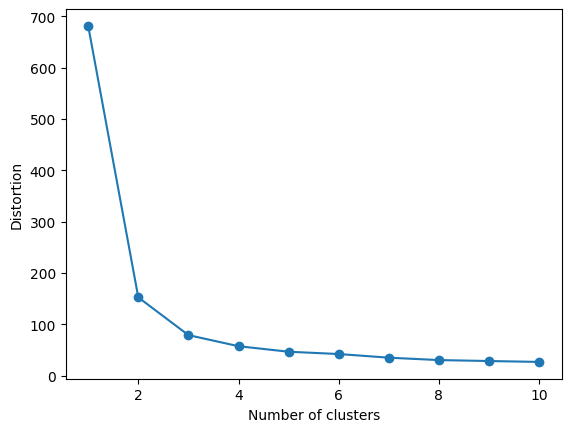

In [5]:
# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

#এলবো মেথড প্লট: ক্লাস্টার সংখ্যা বনাম distortion এর গ্রাফ।
#marker='o' → পয়েন্টগুলো বৃত্ত দিয়ে চিহ্নিত।
#লেবেল ও শিরোনাম যোগ করে প্লট দেখানো।

In [6]:
distortions=distortions/np.max(distortions) # distortion ভ্যালুগুলোকে নরমালাইজ করা (সবচেয়ে বড় মান দিয়ে ভাগ)।
distortions # নরমালাইজড ভ্যালু প্রিন্ট করা।


array([1.        , 0.22359044, 0.11572475, 0.08399023, 0.06816581,
       0.06159095, 0.05113992, 0.04430052, 0.04158307, 0.03902488])

In [7]:
for i in range(np.size(distortions)):
  print(distortions[i])
  if((distortions[i]-distortions[i+1])<.1):
    break
k=i+1
k

#নরমালাইজড distortion মান প্রিন্ট করা।
#যদি দুটি consecutive distortion মানের পার্থক্য 0.1 এর কম হয়, তখন লুপ ব্রেক করা।
#k = i+1 → optimal ক্লাস্টার সংখ্যা নির্ধারণ।
#k এর মান প্রিন্ট করা

1.0
0.2235904392710194
0.1157247486553515


3

In [8]:
#instantiat Kmeans
km = KMeans(k) # optimal k সংখ্যা দিয়ে KMeans মডেল তৈরি।
clusts = km.fit_predict(X) # ডেটাকে ক্লাস্টার করে প্রতিটি পয়েন্টের ক্লাস্টার লেবেল রিটার্ন করে

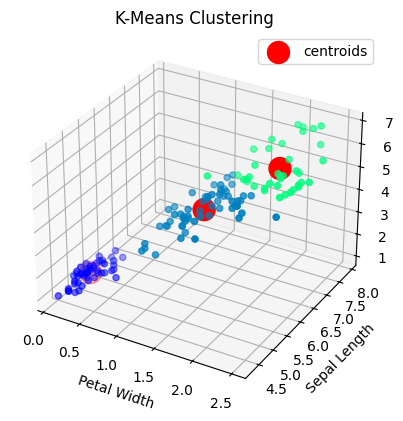

In [9]:
#plot the cluster
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(km.cluster_centers_[:, 3],
            km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 2],
            s = 250,
            marker='o',
            c='red',
            label='centroids')
scatter = ax.scatter(df['petal width (cm)'],df['sepal length (cm)'], df['petal length (cm)'],
                     c=clusts,s=20, cmap='winter')


ax.set_title('K-Means Clustering')
ax.set_xlabel('Petal Width')
ax.set_ylabel('Sepal Length')
ax.set_zlabel('Petal Length')
ax.legend()
plt.show()

""""

3D প্লট তৈরির জন্য ফিগার ও অক্ষ অবজেক্ট তৈরি।

প্রথম scatter → ক্লাস্টার সেন্টার পয়েন্ট (লাল, বড় বৃত্ত)।

km.cluster_centers_[:, 3] → petal width সেন্টার।

km.cluster_centers_[:, 0] → sepal length সেন্টার।

km.cluster_centers_[:, 2] → petal length সেন্টার।

দ্বিতীয় scatter → আসল ডেটা পয়েন্ট, রং ক্লাস্টার লেবেল অনুযায়ী (winter colormap)।

অক্ষের নাম ও শিরোনাম সেট করা।

লেজেন্ড ও প্লট দেখানো।

"""